In [7]:
import rasterio as rs
import numpy as np
import matplotlib.pyplot as plt

import geopandas as gpd
import shapely
import fiona
import pandas as pd
import json
import os
from glob import glob
from shapely.geometry import Polygon

from sklearn.metrics import f1_score
from sarpy.visualization.remap import density
from rasterio.windows import from_bounds
from shapely.geometry import box
from shapely.ops import unary_union

from datetime import timedelta, datetime, date
from shapely import is_valid, is_valid_reason, make_valid
import networkx as nx
from pathlib import Path


In [8]:
def parse_times(survey_date_precision, survey_date, start=True):
    if '+/-' in survey_date_precision:
        delta = int(survey_date_precision.split('+/- ')[1].split(' days')[0])
        if start:
            return survey_date - timedelta(days=delta)
        else:
            # end date
            return survey_date + timedelta(days=delta) 
        
    else:
        
        start_date, end_date  = survey_date_precision.split('-')
        start_month, start_year = start_date.split('/')
        start_month = int(start_month)
        start_year = int(start_year)
        end_month, end_year = end_date.split('/')
        end_month = int(end_month)
        end_year = int(end_year)
        
        if start:
            return date(start_year, start_month, day=1)
        else:
            return date(end_year, end_month, day=1)

In [9]:
def get_folder_size(parent, glob_query='*'):
    return ByteSize(sum(file.stat().st_size for file in Path(parent).rglob(glob_query)))

class ByteSize(int):

    _KB = 1024
    _suffixes = 'B', 'KB', 'MB', 'GB', 'PB'

    def __new__(cls, *args, **kwargs):
        return super().__new__(cls, *args, **kwargs)

    def __init__(self, *args, **kwargs):
        self.bytes = self.B = int(self)
        self.kilobytes = self.KB = self / self._KB**1
        self.megabytes = self.MB = self / self._KB**2
        self.gigabytes = self.GB = self / self._KB**3
        self.petabytes = self.PB = self / self._KB**4
        *suffixes, last = self._suffixes
        suffix = next((
            suffix
            for suffix in suffixes
            if 1 < getattr(self, suffix) < self._KB
        ), last)
        self.readable = suffix, getattr(self, suffix)

        super().__init__()

    def __str__(self):
        return self.__format__('.2f')

    def __repr__(self):
        return '{}({})'.format(self.__class__.__name__, super().__repr__())

    def __format__(self, format_spec):
        suffix, val = self.readable
        return '{val:{fmt}} {suf}'.format(val=val, fmt=format_spec, suf=suffix)

    def __sub__(self, other):
        return self.__class__(super().__sub__(other))

    def __add__(self, other):
        return self.__class__(super().__add__(other))
    
    def __mul__(self, other):
        return self.__class__(super().__mul__(other))

    def __rsub__(self, other):
        return self.__class__(super().__sub__(other))

    def __radd__(self, other):
        return self.__class__(super().__add__(other))
    
    def __rmul__(self, other):
        return self.__class__(super().__rmul__(other))   

# **Process DEFID2**

----------

## Read gdb

In [ ]:
gdf_defid2 = gpd.read_file('defid2/raw/defid2.gpkg')

In [11]:
gdf_defid2 = gdf_defid2[gdf_defid2.agents.isin(['Ips typographus'])]
gdf_defid2 = gdf_defid2[gdf_defid2.country.isin(['Czechia'])]
gdf_defid2 = gdf_defid2.sort_values('survey_date')

gdf_defid2.event_id = gdf_defid2.event_id.astype(int)
gdf_defid2.survey_date = pd.to_datetime(gdf_defid2.survey_date)
gdf_defid2['label'] = 'infected'

## Convert datetimes to start/end datetime

In [12]:
gdf_defid2['start_time'] = gdf_defid2.apply(lambda r: parse_times(r['survey_date_precision'],
                                                                            r['survey_date'], start=True),
                                                     axis=1)
gdf_defid2['start_time'] = pd.to_datetime(gdf_defid2['start_time'])

gdf_defid2['end_time'] = gdf_defid2.apply(lambda r: parse_times(r['survey_date_precision'],
                                                                          r['survey_date'], start=False),
                                                     axis=1)
gdf_defid2['end_time'] = pd.to_datetime(gdf_defid2['end_time'])

## Convert CRS to regional

In [13]:
gdf_defid2 = gdf_defid2.to_crs(32633)
gdf_defid2.set_index('event_id', inplace=True)
gdf_defid2.index = gdf_defid2.index.astype(int)
gdf_defid2['event_id_re'] = gdf_defid2.index

## Check for valid geoms

In [14]:
gdf_defid2['valid_geometry'] = gdf_defid2['geometry'].apply(lambda r : is_valid(r))
gdf_defid2 = gdf_defid2[gdf_defid2['valid_geometry']]

## Filter by valid survey precisions

In [18]:
# SELECT WHICH SURVEY DATES YOU WANT HERE

# valid_survey_prec = ['01/2018-09/2018', '11/2018-09/2019', '11/2019-09/2020', '11/2020-09/2021']
valid_survey_prec = ['11/2020-09/2021']

gdf_defid2 = gdf_defid2[gdf_defid2.survey_date_precision.isin(valid_survey_prec)]

In [16]:
gdf_defid2['geom_bbox'] = gdf_defid2.geometry.apply(lambda r: r.oriented_envelope.envelope)
gdf_defid2['geom_area_bbox'] = gdf_defid2['geom_bbox'].apply(lambda r: r.area)

task_geom_bounds = gdf_defid2['geom_bbox'].bounds
gdf_defid2['geom_bbox_width'] = task_geom_bounds.maxx - task_geom_bounds.minx
gdf_defid2['geom_bbox_height'] = task_geom_bounds.maxy - task_geom_bounds.miny

In [17]:
gdf_defid2['geom_area'] = gdf_defid2['geometry'].apply(lambda r: r.area)

## Cluster by proximity

In [19]:
PROX_THRES = 512 # proximity threshold in meters

survey_dates = gdf_defid2['survey_date'].unique().tolist()
new_max=0
mappings=[]

# make buffered copy
for s in survey_dates:
    gdf_defid2_survey = gdf_defid2[gdf_defid2['survey_date']==s] #.copy()
    print(s, gdf_defid2_survey.shape)

    buffers = gdf_defid2_survey.copy()
    buffers["geometry"] = gdf_defid2_survey.buffer(PROX_THRES)

    # find adjacency
    pairs = gpd.sjoin(gdf_defid2_survey, buffers, how="left", predicate="intersects")
    edges = pairs[["event_id_re_left", "event_id_re_right"]].dropna().astype(int).values.tolist()

    # connected components
    G = nx.Graph()
    G.add_edges_from(edges)
    mapping = {idx: i+new_max for i, comp in enumerate(nx.connected_components(G)) for idx in comp}
    new_max += max(mapping.values()) + 1

    mappings.append(mapping)

2021-09-30 00:00:00 (255475, 37)


In [20]:
combined_mapping = {}
for d in mappings:
    combined_mapping.update(d)
    
gdf_defid2["cluster_id"] = gdf_defid2.index.map(combined_mapping)
clusters = gdf_defid2.dissolve(by="cluster_id")

In [21]:
clusters.shape

(18904, 37)

In [22]:
assert len(gdf_defid2.groupby('cluster_id')['survey_date'].unique().values.tolist()) == clusters.shape[0]

In [23]:
clusters = clusters.reset_index()

In [24]:
clusters.rename(columns={"geometry": "cluster_geom"}, inplace=True)

In [27]:
# Create clutter (background polys)
clusters['cluster_geom_clutter'] = clusters.cluster_geom.apply(lambda g : g.buffer(PROX_THRES).difference(g))

# merge all instances
gdf_cluster_merge = clusters[['cluster_id', 'cluster_geom', 'cluster_geom_clutter']].merge(gdf_defid2, on='cluster_id', how='inner')

##### comparison of main geom example vs background poly

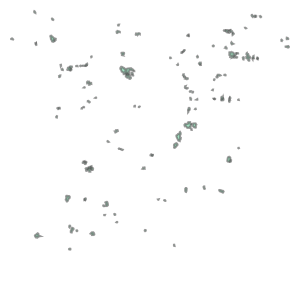

In [28]:
gdf_cluster_merge.iloc[0].cluster_geom

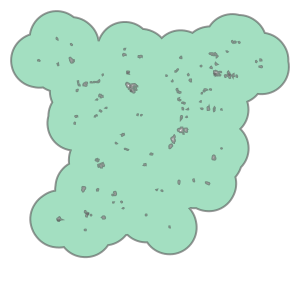

In [29]:
gdf_cluster_merge.iloc[0].cluster_geom_clutter

## Create task geometries

In [30]:
df_with_grid = gdf_cluster_merge.copy()
df_with_grid['event_id_split'] = list(range(df_with_grid.shape[0]))

In [31]:
df_with_grid['task_geom'] = df_with_grid.geometry.apply(lambda r: r.oriented_envelope.envelope)
df_with_grid['task_geom_area'] = df_with_grid['task_geom'].apply(lambda r: r.area)

task_geom_bounds = df_with_grid['task_geom'].bounds
df_with_grid['task_geom_width'] = task_geom_bounds.maxx - task_geom_bounds.minx
df_with_grid['task_geom_height'] = task_geom_bounds.maxy - task_geom_bounds.miny

In [32]:
MIN_HW_METERS = 64 * 3 #64pix * 3m/pix -->> this is based on patch sized used in Olmo (64 pix in config)
EPS = 10 # buffer in meters

# find min sude
df_with_grid['min_side'] = np.minimum(df_with_grid.task_geom_width.values, df_with_grid.task_geom_height.values)

# buffer by min side diff
df_with_grid['min_buffer'] = np.maximum(0, MIN_HW_METERS - df_with_grid['min_side'] + EPS)

# apply buffer to task_geom - this new column will be used in the OER processing python script
df_with_grid['task_geom_buff'] = df_with_grid.apply(lambda r: r['task_geom'].buffer(r.min_buffer, 
                                                                                    cap_style='square', 
                                                                                    join_style='mitre'), 
                                                    axis=1)

In [33]:
df_with_grid['valid_geometry'] = df_with_grid['geometry'].apply(lambda r : is_valid(r))
df_with_grid = df_with_grid[df_with_grid['valid_geometry']]
df_with_grid.shape

(255475, 48)

# Save out

In [ ]:
cols = ['geom_ids','survey_date', 'survey_date_precision', 
        'task_geom', 'task_geom_buff',
        'clutter_label', 'label',
        'start_time', 'end_time', 'geom_area',
        'cluster_geom', 'cluster_geom_clutter', 'geometry']

df_with_grid['clutter_label'] = 'clutter'
df_master = df_with_grid[cols]

df_master['event_id_split'] = list(range(df_master.shape[0]))
df_master.set_geometry('geometry', inplace=True)

In [ ]:
df_master['cluster_geom'] = df_master.apply(lambda r: r['cluster_geom'].intersection(r.task_geom_buff), axis=1)

In [ ]:
df_master['cluster_geom_clutter'] = df_master.apply(lambda r: r['cluster_geom_clutter'].intersection(r.task_geom_buff), axis=1)

In [ ]:
df_master['cluster_geom'].iloc[0]

In [ ]:
df_master['cluster_geom_clutter'].iloc[0]

In [ ]:
tmp = gpd.GeoSeries(df_master["task_geom"], crs=df_master.crs)
task_bbox_wgs84 = tmp.to_crs(4326).envelope
df_master['task_geom'] = task_bbox_wgs84.to_wkt()

tmp = gpd.GeoSeries(df_master["task_geom_buff"], crs=df_master.crs)
task_bbox_wgs84 = tmp.to_crs(4326).envelope
df_master['task_geom_buff'] = task_bbox_wgs84.to_wkt()

df_master = df_master.to_crs('EPSG:4326')
df_master.set_geometry('geometry', inplace=True)

In [ ]:
df_master['cluster_geom'].set_crs(32633, inplace=True)

In [ ]:
df_master['cluster_geom_clutter'].set_crs(32633, inplace=True)

##### Save out the geodataframes

In [ ]:
PRIMARY_FP = f'cluster_all.gdb'
CLUTTER_FP = f'cluster_all_clutter.gdb'

#save out
df_master.drop(['cluster_geom_clutter', 'geometry'], axis=1).set_geometry('cluster_geom').to_file(PRIMARY_FP, driver="GPKG")
df_master.drop(['cluster_geom', 'geometry'], axis=1).set_geometry('cluster_geom_clutter').to_file(CLUTTER_FP, driver="GPKG")

## Convert to KML

In [ ]:
df_with_grid.to_file("cluster_all.kml", driver='KML')

# Join with buffered labels

In [27]:
from tqdm import tqdm
from multiprocessing import Pool
import os

In [52]:
def proc_lab_raster(id_):
    orig_taskid = id2taskid[id_]
    anti_taskid = antiid2taskid[id_]

    orig_file = f'oerun_cluster_30d/dataset/windows/spatial_split_10km/task_{orig_taskid}_polygon_window/layers/label/label/geotiff.tif'

    img_rs_orig = rs.open(orig_file)
    img_rs_anti = rs.open(f'oerun_cluster_30d_clutter/dataset/windows/spatial_split_10km/task_{anti_taskid}_polygon_window/layers/label/geotiff.tif')

    img_orig = img_rs_orig.read(1)
    
    if (0 in img_orig) and (1 not in img_orig):
        
        img_anti = img_rs_anti.read(1)

        assert img_orig.shape == img_anti.shape, f'orig shape: {img_orig.shape}; anti shape: {img_anti.shape}...check to make sure task geometries are equal'

        # write here
        img_anti[img_orig==0] = 1

        with rs.open(orig_file, "w", **img_rs_orig.profile) as dst:
            dst.write(img_anti, 1)

In [53]:
orig_annos = json.load(open(f'processed_cluster_30d/annotation_task_features.geojson', 'r'))
anti_annos = json.load(open(f'processed_cluster_30d_clutter/annotation_task_features.geojson', 'r'))

In [56]:
id2taskid = dict()
for ann in orig_annos['features']:
    id2taskid[int(ann['properties']['src_feature_id'])] = ann['properties']['oe_annotations_task_id']
    
antiid2taskid = dict()
for ann in anti_annos['features']:
    antiid2taskid[int(ann['properties']['src_feature_id'])] = ann['properties']['oe_annotations_task_id']

In [ ]:
len(id2taskid)

In [ ]:
len(antiid2taskid)

In [ ]:
with Pool(os.cpu_count()-1) as p:
    results = list(
        tqdm(
            p.imap_unordered(proc_lab_raster, id2taskid.keys()),
            total=len(id2taskid),
            desc="Processing rasters (unordered)"
        )
    )

#### Test read new rasterized label

In [ ]:
fp = f'oerun_cluster_30d_trim/dataset/windows/spatial_split_10km/task_00001386-f35b-5e75-aad0-fa389b5e9bb6_polygon_window/layers/label/label/geotiff.tif'
img_rs = rs.open(fp)
img = img_rs.read(1)

In [ ]:
plt.imshow(np.ma.array(img, mask=img==255))
plt.colorbar()